# **ARIMA Models**

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TestDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
import pmdarima

import warnings

warnings.filterwarnings("ignore")


In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TestDataFrame()

# **ARIMA Univariate**

In [3]:
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2025-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 20 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = pmdarima.auto_arima(y=Training_Target)

        try:
            prediction = MODEL.predict(n_periods=prediction_length)
        except:
            prediction = [Training_Target.iloc[-1]]
        
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        
        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        

        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    

    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()

ACN 2.855087150251331
ACN 0.8656986383084433
ACN 1.0063670309185102
ACN 3.2874859136207384
ACN 0.6509247771519306
ACN 1.6503176119448373
ACN 0.10326963561169111
ACN 1.910877324211963
ACN 1.616019719364064
ACN 1.4736371222877893
ACN 0.8066893815486751
ACN 0.6876930548679527
ACN 0.25893573093527833
ACN 2.1245426526697964
ACN 1.416262960115347
ACN 2.459527023007352
ACN 1.2905075526207197
ACN 0.47931793546809925
ACN 0.9890649085149248
ACN 1.2067133524120626
ACN 0.6085987996986224
ACN 0.7125602907086639
ACN 2.4155713118075397
ACN 1.9938132369842758
ACN 0.3900454279403054
ACN 0.2943961751610963
ACN 4.260305124441174
ACN 2.059543880585802
ACN 1.4604962783015163
ACN 0.9949589050069281
ACN 1.8443997192382995
ACN 4.662817975912661
ACN 5.833648618518934
ACN 5.713949983783777
ACN 3.063278570814507
ACN 1.0315465838089817
ACN 0.03376973279197936
ACN 1.124178678818595
ACN 0.9881722244300937
ACN 0.6842497824929759
ACN 0.43820977025509306
ACN 1.128670378716406
ACN 1.5631778531951739
ACN 0.6016044491564

In [4]:
means_prevalences = [np.mean(i) for i in performance_simple.values()]
100*np.mean(means_prevalences)
# 0.444066099148723

np.float64(56.67887667887668)

In [5]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [6]:
np.mean(list(mean_performances.values()))

np.float64(1.9231969096621602)

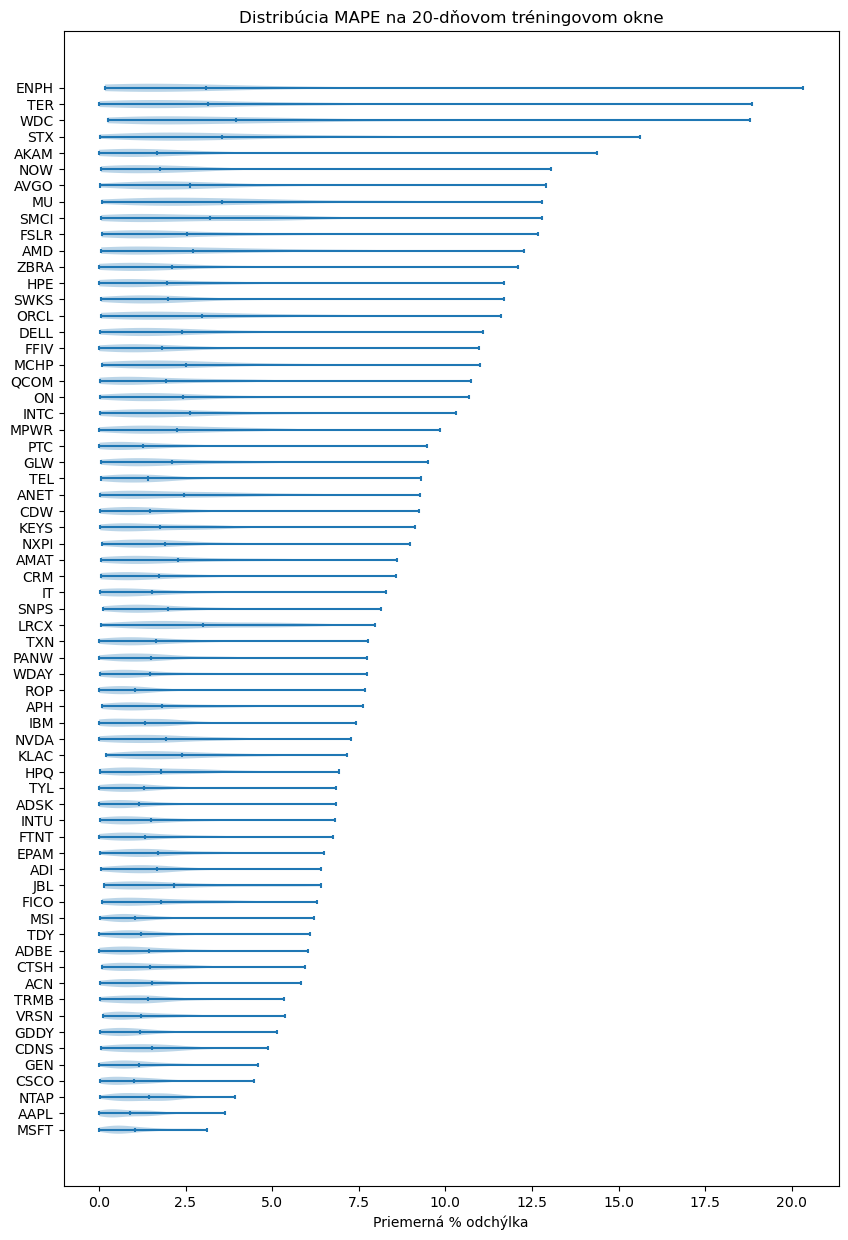

In [7]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [8]:
mean_performances

{'AAPL': np.float64(0.9076011202199322),
 'CSCO': np.float64(1.0213828314178728),
 'MSFT': np.float64(1.0267660212427034),
 'MSI': np.float64(1.0485451084313173),
 'ROP': np.float64(1.0522300746505797),
 'ADSK': np.float64(1.1442121484301206),
 'GEN': np.float64(1.1703047074001196),
 'GDDY': np.float64(1.1973370701682637),
 'TDY': np.float64(1.2019737136085753),
 'VRSN': np.float64(1.215764130809906),
 'PTC': np.float64(1.2803291769691565),
 'TYL': np.float64(1.3097069538862416),
 'IBM': np.float64(1.3223280138244975),
 'FTNT': np.float64(1.3315828532836789),
 'TEL': np.float64(1.4080483474217302),
 'TRMB': np.float64(1.4272249783130666),
 'ADBE': np.float64(1.4455685396951525),
 'NTAP': np.float64(1.447057958747015),
 'CTSH': np.float64(1.4595572183324979),
 'WDAY': np.float64(1.4699348865099675),
 'CDW': np.float64(1.477197668790636),
 'INTU': np.float64(1.4909261028866205),
 'PANW': np.float64(1.5034007288587063),
 'IT': np.float64(1.5363604552553551),
 'CDNS': np.float64(1.54341116

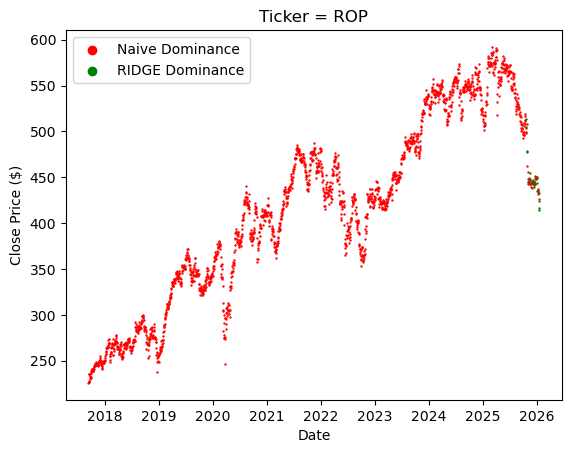

In [9]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ROP"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

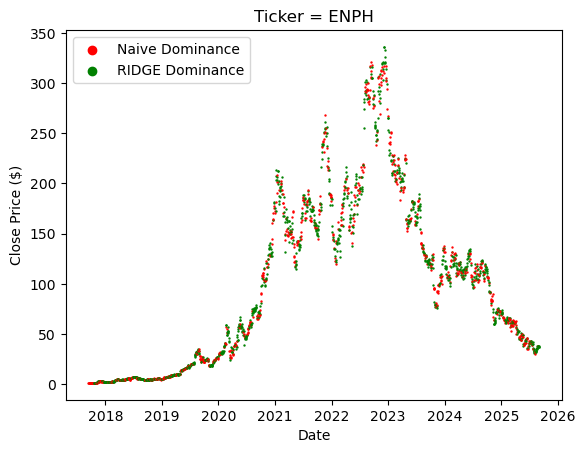

In [57]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ENPH"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

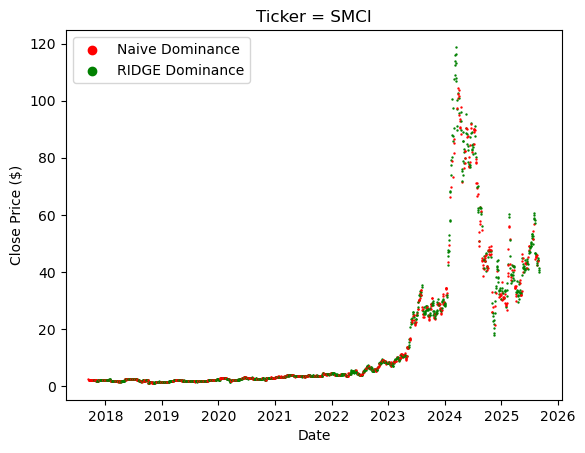

In [58]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "SMCI"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

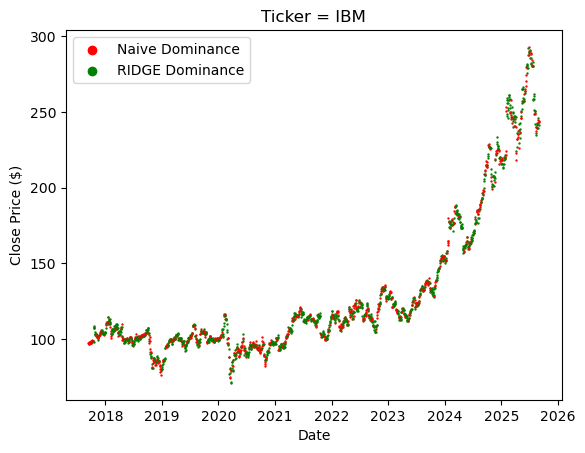

In [59]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "IBM"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

# **Analysis of dominance in detail**

In [60]:
# COVID
# We perform analysis of precision between February and March 2020 -> Covid recession

# Number of trading days -> 41 days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2020-02-01") & (TrainingDataFrame["Date"] <= "2020-03-31")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

covid_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    covid_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(covid_dominances.values())))

58.98686679174485


In [61]:
sorted(covid_dominances.items(), key=lambda x: x[1], reverse=True)

[('NOW', 78.04878048780488),
 ('CTSH', 73.17073170731707),
 ('FICO', 73.17073170731707),
 ('FSLR', 73.17073170731707),
 ('INTC', 73.17073170731707),
 ('INTU', 70.73170731707317),
 ('TEL', 70.73170731707317),
 ('TYL', 70.73170731707317),
 ('AAPL', 68.29268292682927),
 ('ENPH', 68.29268292682927),
 ('MU', 68.29268292682927),
 ('MSI', 68.29268292682927),
 ('PTC', 68.29268292682927),
 ('QCOM', 68.29268292682927),
 ('CDW', 65.85365853658537),
 ('GEN', 65.85365853658537),
 ('KEYS', 65.85365853658537),
 ('LRCX', 65.85365853658537),
 ('ADBE', 63.41463414634146),
 ('ADI', 63.41463414634146),
 ('MSFT', 63.41463414634146),
 ('NXPI', 63.41463414634146),
 ('ON', 63.41463414634146),
 ('WDC', 63.41463414634146),
 ('FFIV', 60.97560975609756),
 ('IT', 60.97560975609756),
 ('IBM', 60.97560975609756),
 ('KLAC', 60.97560975609756),
 ('ROP', 60.97560975609756),
 ('STX', 60.97560975609756),
 ('AMAT', 58.53658536585366),
 ('GLW', 58.53658536585366),
 ('EPAM', 58.53658536585366),
 ('SWKS', 58.53658536585366),

In [62]:
# Trumpove mecheche
# We perform analysis of precision between of April 2025 -> Trump's tarrifs

# Number of trading days -> 41 days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2025-04-01") & (TrainingDataFrame["Date"] <= "2025-04-30")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

trump_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    trump_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(trump_dominances.values())))

58.02197802197803


In [63]:
sorted(trump_dominances.items(), key=lambda x: x[1], reverse=True)

[('ACN', 100.0),
 ('CDW', 80.95238095238095),
 ('MCHP', 80.95238095238095),
 ('ADBE', 76.19047619047619),
 ('CSCO', 76.19047619047619),
 ('CTSH', 76.19047619047619),
 ('ADI', 71.42857142857143),
 ('MU', 71.42857142857143),
 ('TDY', 71.42857142857143),
 ('WDC', 71.42857142857143),
 ('ANET', 66.66666666666667),
 ('DELL', 66.66666666666667),
 ('EPAM', 66.66666666666667),
 ('GDDY', 66.66666666666667),
 ('NXPI', 66.66666666666667),
 ('CRM', 66.66666666666667),
 ('STX', 66.66666666666667),
 ('SMCI', 66.66666666666667),
 ('TXN', 66.66666666666667),
 ('ZBRA', 66.66666666666667),
 ('AKAM', 61.904761904761905),
 ('GLW', 61.904761904761905),
 ('FFIV', 61.904761904761905),
 ('IT', 61.904761904761905),
 ('GEN', 61.904761904761905),
 ('NTAP', 61.904761904761905),
 ('NVDA', 61.904761904761905),
 ('ORCL', 61.904761904761905),
 ('TRMB', 61.904761904761905),
 ('AMD', 57.142857142857146),
 ('FSLR', 57.142857142857146),
 ('IBM', 57.142857142857146),
 ('KEYS', 57.142857142857146),
 ('LRCX', 57.142857142857

In [64]:
years = [str(i) for i in range(2017, 2026)]
dominances = []

for year in years:
    trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= f"{year}-01-01") & (TrainingDataFrame["Date"] <= f"{year}-12-31")]["Date"].values
    trading_days = [str(i).split("T")[0] for i in trading_days]

    year_dominances = {}

    for ticker in tickers["Ticker"]:
        counter = 0
        for day in model_dominance[ticker]:
            if day in trading_days:
                counter += 1
        year_dominances[ticker] = counter*100 / len(trading_days)

    dominances.append(np.mean(list(year_dominances.values())))
    print(year, np.mean(list(year_dominances.values())))

2017 41.78794178794179
2018 57.50536316273368
2019 58.907203907203915
2020 58.218303435694736
2021 57.246642246642246
2022 59.33803248544284
2023 58.7323076923077
2024 58.34554334554335
2025 56.20451404882543
